# Project1 : Shape Feature & Fourier Descriptors

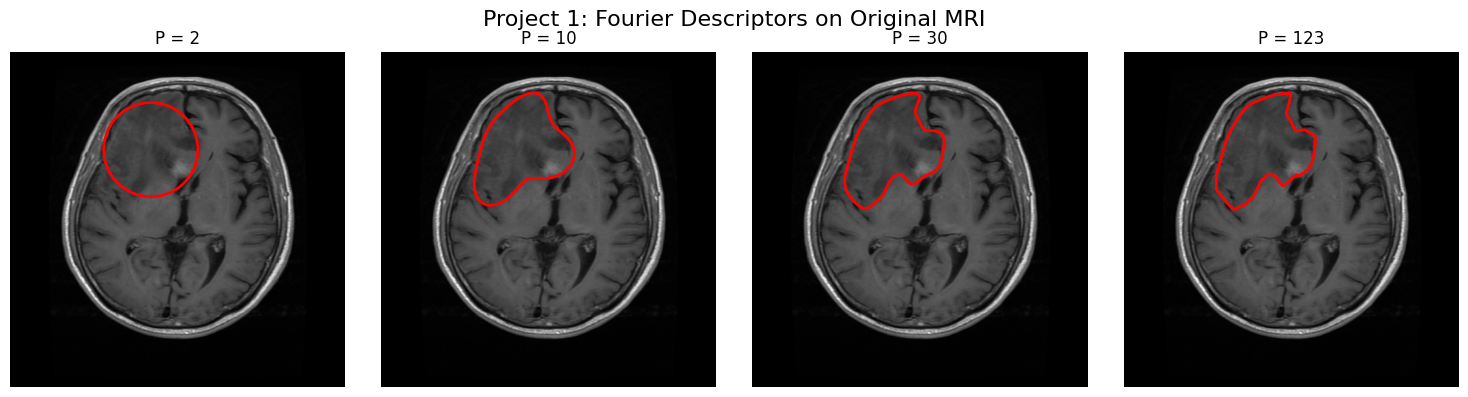

In [4]:
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# ================= 1. 数据读取 (使用 h5py) =================
file_path = 'data/209.mat' 

if not os.path.exists(file_path):
    print(f"找不到文件：{file_path}，请检查 data 文件夹和文件是否存在！")
    exit()

with h5py.File(file_path, 'r') as mat:
    # 提取肿瘤掩膜 (Mask)，用来寻找轮廓
    mask_data = np.array(mat['cjdata']['tumorMask'])
    tumor_mask = mask_data.T.astype(np.uint8) 
    
    # 【新增代码】：提取原始 MRI 脑部图像，用于背景显示
    image_data = np.array(mat['cjdata']['image'])
    original_image = image_data.T 

# ================= 2. 提取真实轮廓 =================
# 寻找掩膜的边缘
contours, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
original_contour = max(contours, key=cv2.contourArea) # 获取最大的那一个轮廓
num_points = len(original_contour)

# ================= 3. 核心算法：傅里叶描述子 =================
# 把 (x, y) 坐标变成复数 x + yi，然后做傅里叶变换
complex_contour = original_contour[:, 0, 0] + 1j * original_contour[:, 0, 1]
fd = np.fft.fft(complex_contour)

# ================= 4. 实验观察：改变 P 值并重建 =================
# 这里我们选择 4 个不同的 P 值来观察
P_values = [2, 10, 30, num_points // 4] 

plt.figure(figsize=(15, 4))
plt.suptitle('Project 1: Fourier Descriptors on Original MRI', fontsize=16)

for i, P in enumerate(P_values):
    # --- 开始截断高频，保留 P 个低频 ---
    fd_shifted = np.fft.fftshift(fd)
    truncated_fd = np.zeros_like(fd_shifted)
    
    center = len(fd_shifted) // 2
    half_P = P // 2
    start_idx = max(0, center - half_P)
    end_idx = min(len(fd_shifted), center + half_P)
    
    truncated_fd[start_idx:end_idx] = fd_shifted[start_idx:end_idx]
    
    # --- 逆傅里叶变换，重建轮廓 ---
    reconstructed_complex = np.fft.ifft(np.fft.ifftshift(truncated_fd))
    recon_x = np.real(reconstructed_complex)
    recon_y = np.imag(reconstructed_complex)
    
    # --- 画图展示 ---
    plt.subplot(1, len(P_values), i + 1)
    
    # 【修改代码】：背景换成原始的 MRI 图像
    plt.imshow(original_image, cmap='gray') 
    
    # 【修改代码】：把重建的轮廓画成红色实线，完全贴合你提供的参考图风格
    plt.plot(recon_x, recon_y, 'r-', linewidth=2) 
    
    plt.title(f'P = {P}')
    plt.axis('off') # 关闭坐标轴，让图片更干净

plt.tight_layout()
plt.show()

增加了P值数量，更好对比

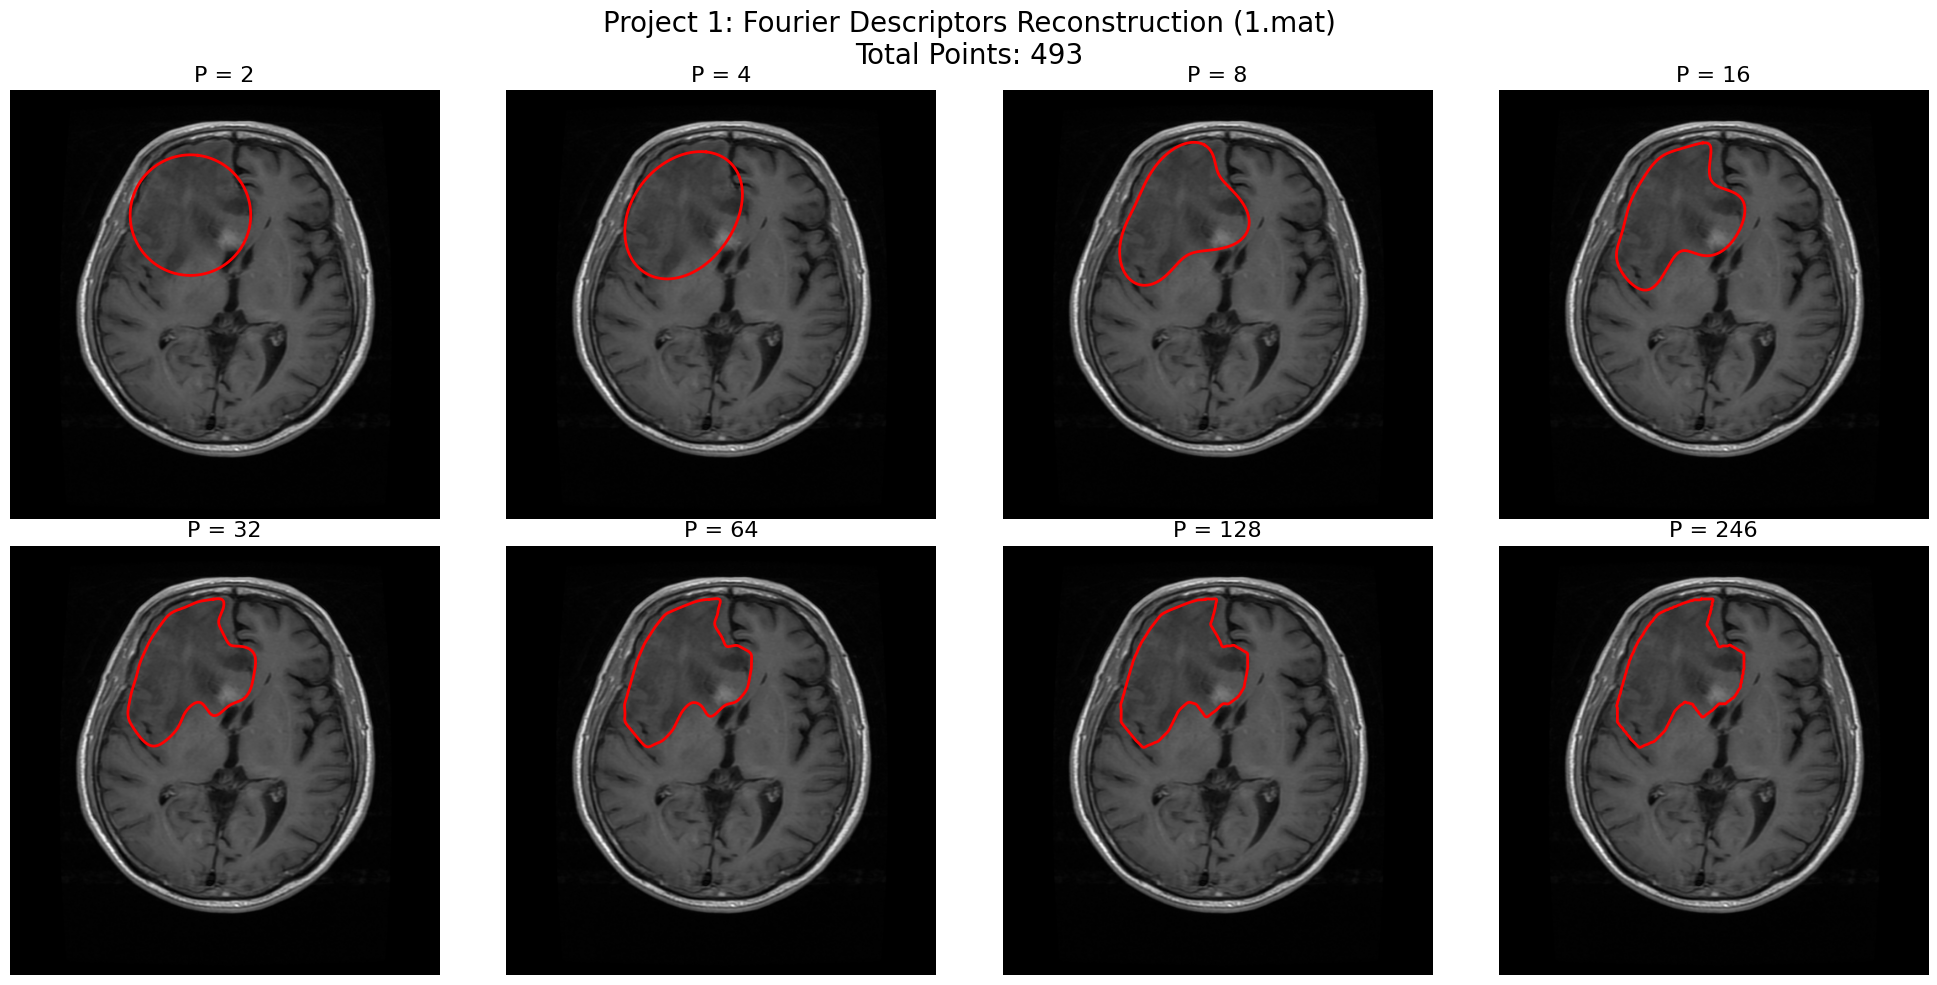

In [5]:
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# ================= 1. 数据读取 (使用 h5py) =================
file_path = 'data/209.mat' 

if not os.path.exists(file_path):
    print(f"找不到文件：{file_path}，请检查 data 文件夹和文件是否存在！")
    exit()

with h5py.File(file_path, 'r') as mat:
    # 提取肿瘤掩膜 (Mask)
    mask_data = np.array(mat['cjdata']['tumorMask'])
    tumor_mask = mask_data.T.astype(np.uint8) 
    
    # 提取原始 MRI 脑部图像
    image_data = np.array(mat['cjdata']['image'])
    original_image = image_data.T 

# ================= 2. 提取真实轮廓 =================
contours, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
original_contour = max(contours, key=cv2.contourArea) 
num_points = len(original_contour)

# ================= 3. 核心算法：傅里叶描述子 =================
complex_contour = original_contour[:, 0, 0] + 1j * original_contour[:, 0, 1]
fd = np.fft.fft(complex_contour)

# ================= 4. 实验观察：8个不同的 P 值 =================
# 【修改代码】：设置 8 个不同的 P 值进行对比
# 建议使用 2 的幂次方递增，这样能最好地展示低频到高频的过渡
P_values = [2, 4, 8, 16, 32, 64, 128, num_points // 2] 

# 【修改代码】：调整画布大小，准备 2 行 4 列的布局
plt.figure(figsize=(20, 10))
plt.suptitle(f'Project 1: Fourier Descriptors Reconstruction (1.mat)\nTotal Points: {num_points}', fontsize=20, y=0.98)

for i, P in enumerate(P_values):
    # --- 截断高频，保留 P 个低频 ---
    fd_shifted = np.fft.fftshift(fd)
    truncated_fd = np.zeros_like(fd_shifted)
    
    center = len(fd_shifted) // 2
    half_P = P // 2
    start_idx = max(0, center - half_P)
    end_idx = min(len(fd_shifted), center + half_P)
    
    truncated_fd[start_idx:end_idx] = fd_shifted[start_idx:end_idx]
    
    # --- 逆傅里叶变换，重建 ---
    reconstructed_complex = np.fft.ifft(np.fft.ifftshift(truncated_fd))
    recon_x = np.real(reconstructed_complex)
    recon_y = np.imag(reconstructed_complex)
    
    # --- 画图展示 (2行4列布局) ---
    plt.subplot(2, 4, i + 1)
    plt.imshow(original_image, cmap='gray') 
    plt.plot(recon_x, recon_y, 'r-', linewidth=2) 
    
    # 动态显示标题，标明当前的 P 值
    plt.title(f'P = {P}', fontsize=16)
    plt.axis('off') 

# 调整子图之间的间距，防止重叠
plt.tight_layout()
plt.subplots_adjust(top=0.9) # 给总标题留出空间
plt.show()

# Project2 : First-Order Stats

--- 算法初始化 ---
计算获得肿瘤质心坐标: (X=327, Y=216)

Iter | ROI Mean ROI Var    ROI Unif ROI Ent  | Full Mean Full Var    Full Unif Full Ent 
---------------------------------------------------------------------------------------------------------
0    | 76.24    1407.54    0.0081   7.1227   | 33.09     2176.54     0.1085    5.1656   
1    | 76.25    1350.03    0.0083   7.0888   | 33.09     2128.65     0.1097    5.1371   
2    | 76.25    1311.75    0.0084   7.0676   | 33.08     2096.80     0.1099    5.1320   
3    | 76.25    1282.01    0.0085   7.0518   | 33.08     2071.93     0.1100    5.1293   
4    | 76.25    1257.73    0.0086   7.0393   | 33.08     2051.09     0.1099    5.1288   
5    | 76.25    1236.88    0.0087   7.0288   | 33.08     2032.88     0.1098    5.1292   
6    | 76.26    1218.51    0.0087   7.0184   | 33.07     2016.54     0.1097    5.1295   
7    | 76.26    1202.16    0.0087   7.0111   | 33.07     2001.80     0.1096    5.1302   
8    | 76.26    1187.43    0.0088   7.0046   | 33.0

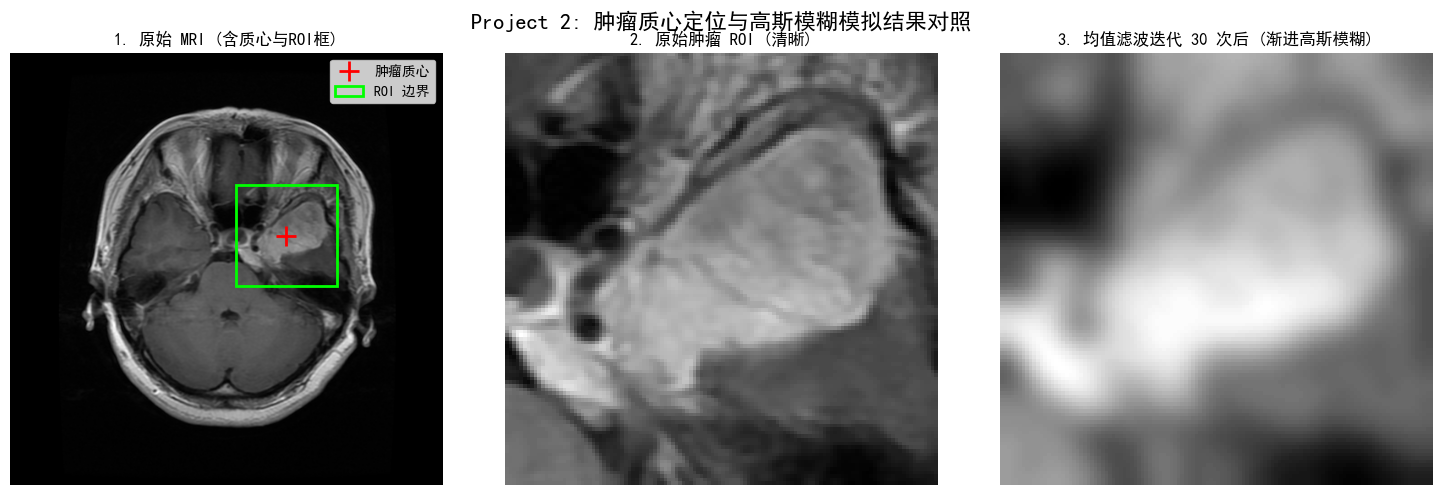

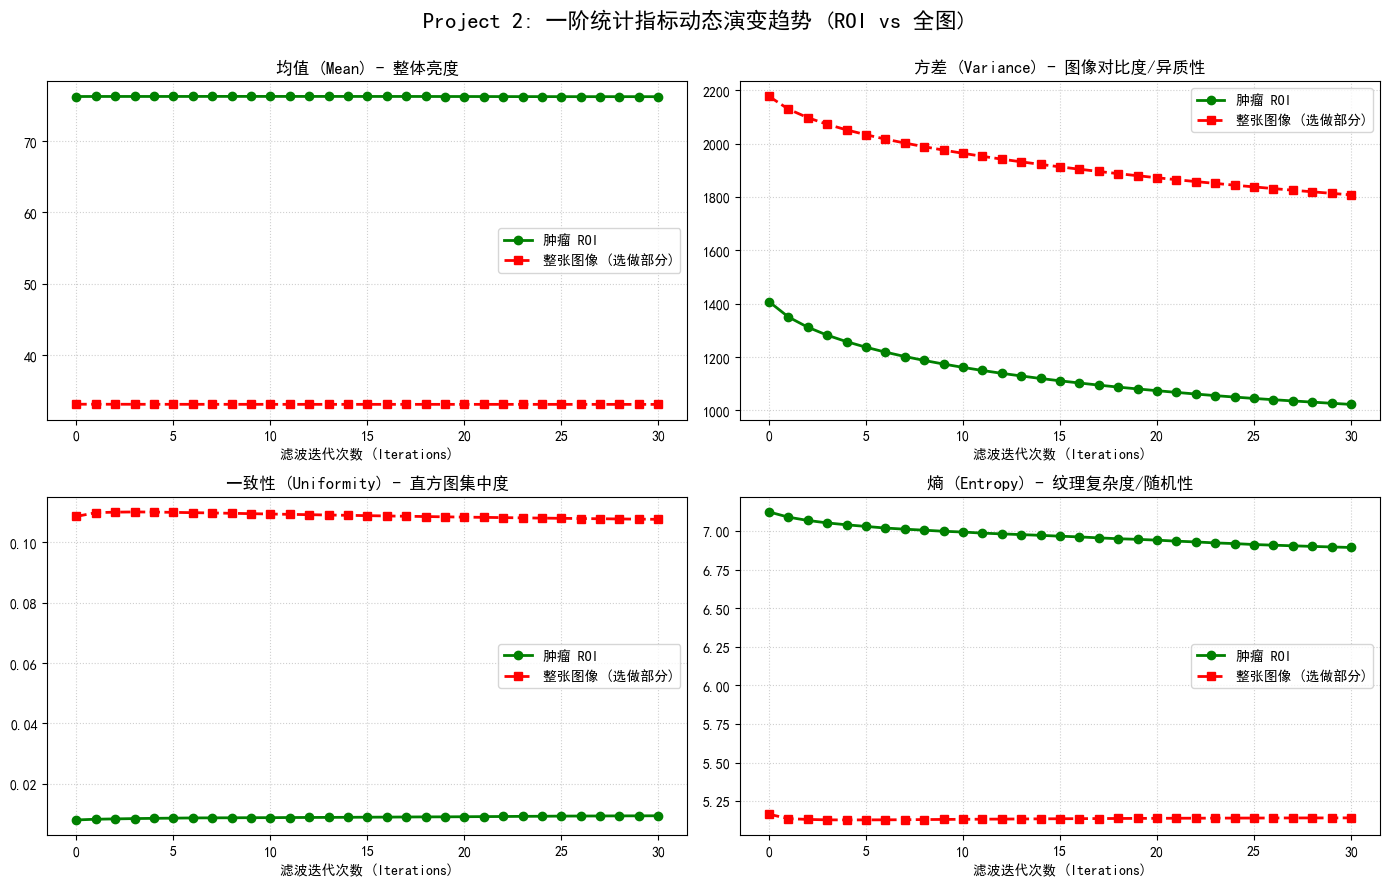

In [11]:
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import warnings

# ================= 0. 环境设置与预处理 =================
# 1. 彻底屏蔽 UserWarning 及其他非致命警告
warnings.filterwarnings("ignore")

# 2. 设置 Matplotlib 的中文字体，确保图表中文和负号显示正常
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC'] 
plt.rcParams['axes.unicode_minus'] = False 

# ================= 1. 数据读取 =================
file_path = 'data/1.mat' 

if not os.path.exists(file_path):
    print(f"找不到文件：{file_path}，请检查 data 文件夹和文件是否存在！")
    exit()

with h5py.File(file_path, 'r') as mat:
    mask_data = np.array(mat['cjdata']['tumorMask'])
    tumor_mask = mask_data.T.astype(np.uint8) 
    
    image_data = np.array(mat['cjdata']['image'])
    img_min, img_max = image_data.min(), image_data.max()
    # 归一化到 0-255 范围，方便计算直方图
    original_image = (((image_data - img_min) / (img_max - img_min)) * 255).T.astype(np.uint8)

# ================= 2. 计算肿瘤质心并确定 ROI 边界 =================
M = cv2.moments(tumor_mask)
cx = int(M['m10'] / M['m00'])
cy = int(M['m01'] / M['m00'])
print(f"--- 算法初始化 ---")
print(f"计算获得肿瘤质心坐标: (X={cx}, Y={cy})\n")

# 以质心为中心，切取 120x120 的矩形区域
half_size = 60
ymin, ymax = max(0, cy - half_size), min(original_image.shape[0], cy + half_size)
xmin, xmax = max(0, cx - half_size), min(original_image.shape[1], cx + half_size)
roi_image = original_image[ymin:ymax, xmin:xmax].copy()

# ================= 3. 统计指标计算函数 =================
def compute_metrics(img_block):
    pixels = img_block.flatten()
    total_pixels = len(pixels)
    
    mean_val = np.mean(pixels)
    var_val = np.var(pixels)
    
    # 计算 256 级的灰度直方图概率分布
    hist, _ = np.histogram(pixels, bins=256, range=(0, 256))
    prob = hist / total_pixels
    
    # 一致性 (Uniformity)
    uniformity_val = np.sum(prob ** 2)
    
    # 熵 (Entropy)
    active_prob = prob[prob > 0]
    entropy_val = -np.sum(active_prob * np.log2(active_prob))
    
    return mean_val, var_val, uniformity_val, entropy_val

# ================= 4. 核心迭代、均值滤波与终端日志打印 =================
max_iters = 30
metrics_roi = {"mean": [], "var": [], "uniformity": [], "entropy": []}
metrics_full = {"mean": [], "var": [], "uniformity": [], "entropy": []}

current_roi = roi_image.copy()
current_full = original_image.copy()

# 打印工整的表头，包含全部 8 个核心指标
print(f"{'Iter':<4} | {'ROI Mean':<8} {'ROI Var':<10} {'ROI Unif':<8} {'ROI Ent':<8} | {'Full Mean':<9} {'Full Var':<11} {'Full Unif':<9} {'Full Ent':<9}")
print("-" * 105)

for i in range(max_iters + 1):
    # 计算当前迭代下的 ROI 和 全图特征
    m_r, v_r, u_r, e_r = compute_metrics(current_roi)
    m_f, v_f, u_f, e_f = compute_metrics(current_full)
    
    # 记录数据用于后续画图
    metrics_roi["mean"].append(m_r)
    metrics_roi["var"].append(v_r)
    metrics_roi["uniformity"].append(u_r)
    metrics_roi["entropy"].append(e_r)
    
    metrics_full["mean"].append(m_f)
    metrics_full["var"].append(v_f)
    metrics_full["uniformity"].append(u_f)
    metrics_full["entropy"].append(e_f)
    
    # 实时向终端输出每一次迭代的全部具体数值（第0次即为原始图像特征）
    print(f"{i:<4} | {m_r:<8.2f} {v_r:<10.2f} {u_r:<8.4f} {e_r:<8.4f} | {m_f:<9.2f} {v_f:<11.2f} {u_f:<9.4f} {e_f:<9.4f}")
    
    # 执行 3x3 均值滤波（最后一次迭代计算完指标后无需再滤波）
    if i < max_iters:
        current_roi = cv2.blur(current_roi, (3, 3))
        current_full = cv2.blur(current_full, (3, 3))

print("-" * 105)
print("计算完成，正在弹出可视化成果窗口...\n")

# ================= 5. 图像可视化：质心与模糊结果 (Figure 1) =================
plt.figure(figsize=(15, 5))
plt.suptitle('Project 2: 肿瘤质心定位与高斯模糊模拟结果对照', fontsize=16)

# 子图 1：原图 + 质心标记 + ROI 绿框
plt.subplot(1, 3, 1) 
plt.imshow(original_image, cmap='gray')
# 【已修复】：将 speakersize 改为正确的 markersize
plt.plot(cx, cy, 'r+', markersize=15, markeredgewidth=2, label='肿瘤质心') 
# 绘制绿色矩形框标出 ROI 区域
rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, edgecolor='lime', facecolor='none', linewidth=2, label='ROI 边界')
plt.gca().add_patch(rect)
plt.title('1. 原始 MRI (含质心与ROI框)')
plt.legend(loc='upper right')
plt.axis('off')

# 子图 2：原始肿瘤 ROI（未模糊）
plt.subplot(1, 3, 2)
plt.imshow(roi_image, cmap='gray')
plt.title('2. 原始肿瘤 ROI (清晰)')
plt.axis('off')

# 子图 3：最终迭代 30 次后的模糊 ROI（模拟高斯模糊结果，对应 PPT Slide 7）
plt.subplot(1, 3, 3)
plt.imshow(current_roi, cmap='gray')
plt.title(f'3. 均值滤波迭代 {max_iters} 次后 (渐进高斯模糊)')
plt.axis('off')

plt.tight_layout()

# ================= 6. 指标动态变化折线图 (Figure 2) =================
iters = np.arange(max_iters + 1)
plt.figure(figsize=(14, 9))
plt.suptitle('Project 2: 一阶统计指标动态演变趋势 (ROI vs 全图)', fontsize=16)

keys = ["mean", "var", "uniformity", "entropy"]
titles = ["均值 (Mean) - 整体亮度", "方差 (Variance) - 图像对比度/异质性", "一致性 (Uniformity) - 直方图集中度", "熵 (Entropy) - 纹理复杂度/随机性"]

for idx, key in enumerate(keys):
    plt.subplot(2, 2, idx + 1)
    plt.plot(iters, metrics_roi[key], 'g-o', linewidth=2, label='肿瘤 ROI')
    plt.plot(iters, metrics_full[key], 'r--s', linewidth=2, label='整张图像 (选做部分)')
    
    plt.title(titles[idx], fontsize=12)
    plt.xlabel('滤波迭代次数 (Iterations)', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.9)

# 同时显示两个窗口
plt.show()

# Project3 : Texture Feature & GLCM Analysis

采样步长 (Distance)    | 对比度 (Contrast)  | 同质性 (Homogeneity)  | 能量 (Energy)
--------------------------------------------------------------------------------
1                      | 0.30                | 0.8695                 | 0.2700
2                      | 0.80                | 0.7692                 | 0.2280
3                      | 1.40                | 0.7018                 | 0.2056
5                      | 2.49                | 0.6212                 | 0.1822
8                      | 3.59                | 0.5579                 | 0.1661
12                     | 4.30                | 0.5204                 | 0.1569
15                     | 4.65                | 0.5019                 | 0.1519
20                     | 5.16                | 0.4760                 | 0.1462
25                     | 5.68                | 0.4477                 | 0.1405
30                     | 6.50                | 0.4179                 | 0.1359


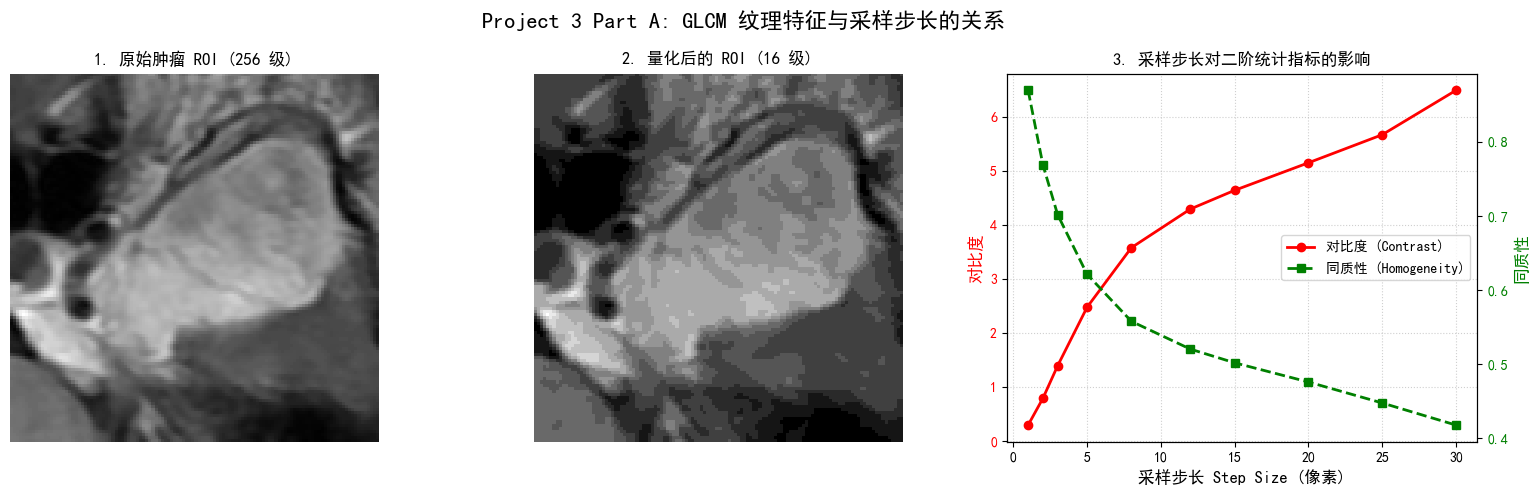

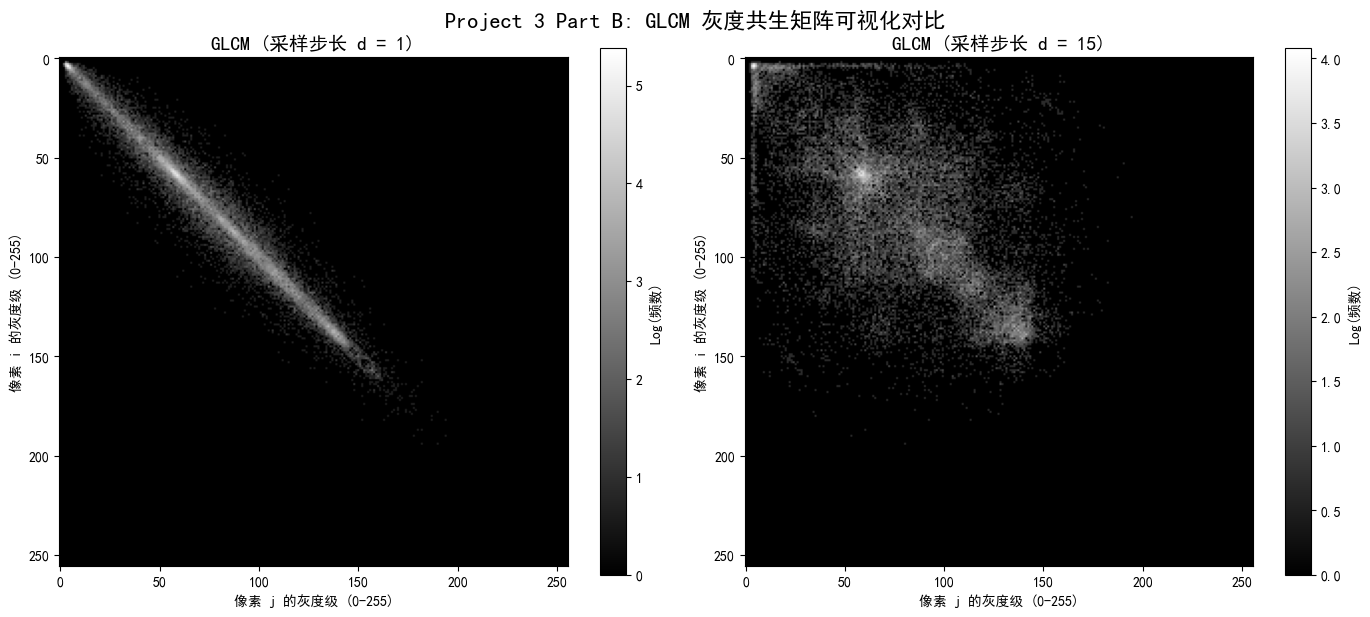

In [16]:
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import os
import warnings

# ================= 0. 环境与画图配置 =================
warnings.filterwarnings("ignore")
# 配置中文字体，Jupyter 中同样适用
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC'] 
plt.rcParams['axes.unicode_minus'] = False 

# ================= 1. 数据读取与 ROI 提取 =================
file_path = 'data/1.mat' 
if not os.path.exists(file_path):
    print(f"找不到文件：{file_path}，请检查当前工作目录下的 data 文件夹！")
else:
    with h5py.File(file_path, 'r') as mat:
        mask_data = np.array(mat['cjdata']['tumorMask'])
        tumor_mask = mask_data.T.astype(np.uint8) 
        
        image_data = np.array(mat['cjdata']['image'])
        img_min, img_max = image_data.min(), image_data.max()
        original_image = (((image_data - img_min) / (img_max - img_min)) * 255).T.astype(np.uint8)

    # 利用质心截取 120x120 的肿瘤局部 ROI
    M = cv2.moments(tumor_mask)
    cx, cy = int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])
    half_size = 60
    ymin, ymax = max(0, cy - half_size), min(original_image.shape[0], cy + half_size)
    xmin, xmax = max(0, cx - half_size), min(original_image.shape[1], cx + half_size)
    roi_image = original_image[ymin:ymax, xmin:xmax].copy()

# ==========================================================
#                   第一部分：二阶纹理特征分析 (16级量化)
# ==========================================================

# 1. 图像灰度量化
levels = 16
roi_quantized = (roi_image / (256 / levels)).astype(np.uint8)

# 2. GLCM 计算与提取 (16级)
distances_feat = [1, 2, 3, 5, 8, 12, 15, 20, 25, 30]
glcm_feat = graycomatrix(roi_quantized, distances=distances_feat, angles=[0], levels=levels, symmetric=True, normed=True)

contrast = graycoprops(glcm_feat, 'contrast').flatten()
homogeneity = graycoprops(glcm_feat, 'homogeneity').flatten()
energy = graycoprops(glcm_feat, 'energy').flatten()

# 3. 打印数据表
print(f"{'采样步长 (Distance)':<18} | {'对比度 (Contrast)':<15} | {'同质性 (Homogeneity)':<18} | {'能量 (Energy)'}")
print("-" * 80)
for i, d in enumerate(distances_feat):
    print(f"{d:<22} | {contrast[i]:<19.2f} | {homogeneity[i]:<22.4f} | {energy[i]:.4f}")

# 4. 绘制特征分析图 (Figure 1)
plt.figure(figsize=(16, 5))
plt.suptitle('Project 3 Part A: GLCM 纹理特征与采样步长的关系', fontsize=16)

plt.subplot(1, 3, 1)
plt.imshow(roi_image, cmap='gray')
plt.title('1. 原始肿瘤 ROI (256 级)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(roi_quantized, cmap='gray')
plt.title(f'2. 量化后的 ROI ({levels} 级)')
plt.axis('off')

ax1 = plt.subplot(1, 3, 3)
ax1.plot(distances_feat, contrast, 'r-o', linewidth=2, label='对比度 (Contrast)')
ax1.set_xlabel('采样步长 Step Size (像素)', fontsize=12)
ax1.set_ylabel('对比度', color='r', fontsize=12)
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(distances_feat, homogeneity, 'g--s', linewidth=2, label='同质性 (Homogeneity)')
ax2.set_ylabel('同质性', color='g', fontsize=12)
ax2.tick_params(axis='y', labelcolor='g')

plt.title('3. 采样步长对二阶统计指标的影响')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show() # 在 Jupyter 中渲染出第一张图

# ==========================================================
#                   第二部分：GLCM 矩阵可视化 (256级原图)
# ==========================================================

# 1. 计算 256 级原图的高分辨率 GLCM
d1, d2 = 1, 15
# 注意这里用的是没有量化的 roi_image，levels=256，不归一化以便肉眼看清频数
glcm_v1 = graycomatrix(roi_image, distances=[d1], angles=[0], levels=256, symmetric=True, normed=False)
glcm_v2 = graycomatrix(roi_image, distances=[d2], angles=[0], levels=256, symmetric=True, normed=False)

# 2. 对数变换以突出暗部细节 (核心步骤)
visual_1 = np.log1p(glcm_v1[:, :, 0, 0])
visual_2 = np.log1p(glcm_v2[:, :, 0, 0])

# 3. 绘制矩阵可视化图 (Figure 2)
plt.figure(figsize=(14, 6))
plt.suptitle('Project 3 Part B: GLCM 灰度共生矩阵可视化对比', fontsize=16)

plt.subplot(1, 2, 1)
plt.imshow(visual_1, cmap='gray')
plt.title(f'GLCM (采样步长 d = {d1})', fontsize=14)
plt.xlabel('像素 j 的灰度级 (0-255)')
plt.ylabel('像素 i 的灰度级 (0-255)')
plt.colorbar(label='Log(频数)')

plt.subplot(1, 2, 2)
plt.imshow(visual_2, cmap='gray')
plt.title(f'GLCM (采样步长 d = {d2})', fontsize=14)
plt.xlabel('像素 j 的灰度级 (0-255)')
plt.ylabel('像素 i 的灰度级 (0-255)')
plt.colorbar(label='Log(频数)')

plt.tight_layout()
plt.show() 